<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/47_classification_evaluation_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

probabilities = rf.predict_proba(X_test)[:,1]

In [5]:
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

f1 = f1_score(
    y_test,
    predictions
)

auc = roc_auc_score(
    y_test,
    probabilities
)

In [6]:
metrics_df = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

metrics_df

,Metric,Value
0,Accuracy,0.920000
1,Precision,0.956522
2,Recall,0.880000
3,F1 Score,0.916667
4,AUC,0.967400


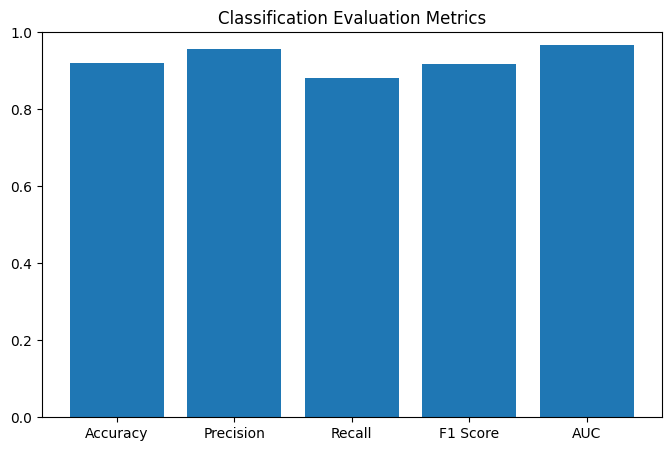

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Metric"],
    metrics_df["Value"]
)

plt.ylim(0,1)

plt.title(
    "Classification Evaluation Metrics"
)

plt.show()

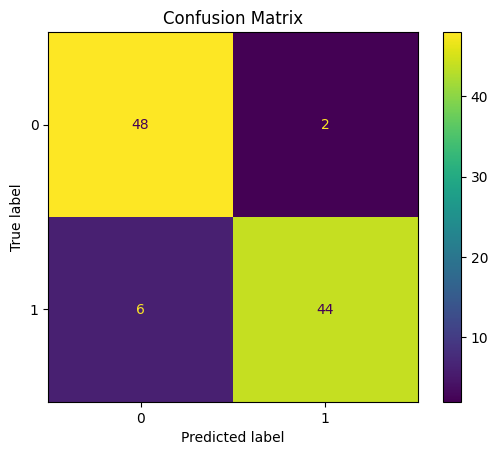

In [8]:
cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Confusion Matrix"
)

plt.show()

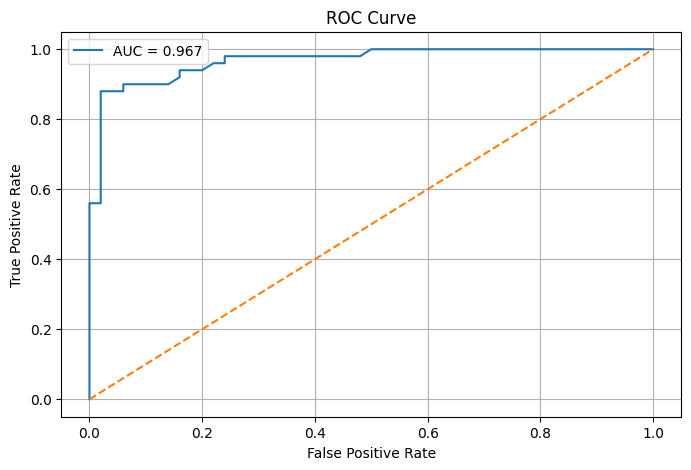

In [9]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.grid()

plt.show()

In [10]:
best_metric = metrics_df.loc[
    metrics_df["Value"].idxmax()
]

print(
    "Highest Metric:"
)

print(best_metric)

Highest Metric:
Metric       AUC
Value     0.9674
Name: 4, dtype: object


## Conclusion

This notebook combined multiple evaluation techniques into a single dashboard.

Observations:
- Accuracy measured overall correctness.
- Precision evaluated prediction reliability.
- Recall measured detection capability.
- F1 Score balanced precision and recall.
- ROC-AUC measured class separation ability.
- Using multiple metrics provides a more complete evaluation than accuracy alone.